<a href="https://colab.research.google.com/github/muzammilhassan-sci/10H-Phenothiazine-derivatives-PCA/blob/main/10H_Phenothiazine_derivatives_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving ligprep_S1_AIDD.csv to ligprep_S1_AIDD.csv


In [3]:
!pip install rdkit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

In [4]:
# Load the dataset
df = pd.read_csv('ligprep_S1_AIDD.csv')
df = df.dropna(subset=['s_user_SMILES'])

# Function to convert SMILES to 1024-bit Morgan Fingerprints
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        return np.array(fp)
    return np.zeros(1024)

# Apply the function across all rows and stack into a 2D matrix
X = np.vstack(df['s_user_SMILES'].apply(smiles_to_fp))


[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerator
[16:39:50] DEPRECATION WARNING: please use MorganGenerat

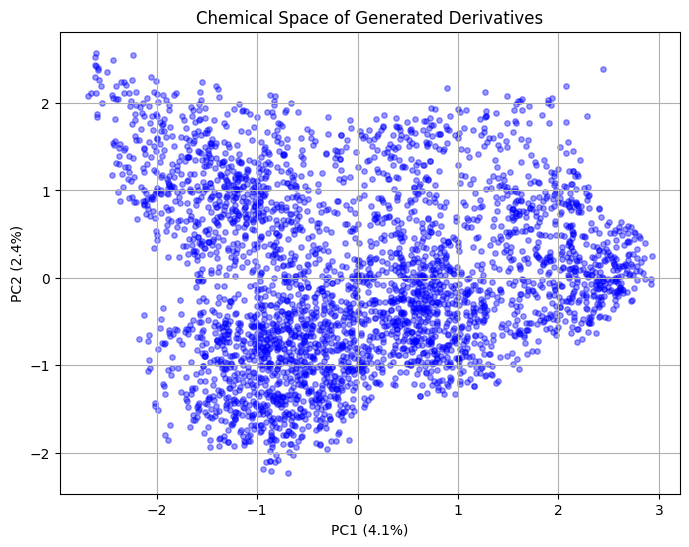

In [5]:
# Initialize and fit PCA for 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Calculate percentage of variance explained
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# Generate scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, c='blue', s=15)
plt.title('Chemical Space of Generated Derivatives')
plt.xlabel(f'PC1 ({var_pc1:.1f}%)')
plt.ylabel(f'PC2 ({var_pc2:.1f}%)')
plt.grid(True)
plt.show()

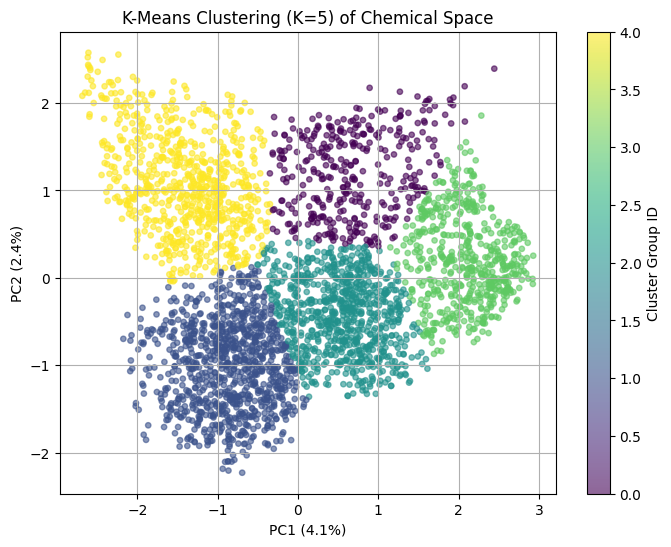

In [6]:
from sklearn.cluster import KMeans

# 1. Initialize the K-Means algorithm
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

# 2. Assign each molecule to a cluster
cluster_labels = kmeans.fit_predict(X_pca)

# 3. Generate the colorful scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=15)

# 4. Add visual aids and labels
plt.colorbar(scatter, label='Cluster Group ID')
plt.title(f'K-Means Clustering (K={k}) of Chemical Space')
plt.xlabel(f'PC1 ({var_pc1:.1f}%)')
plt.ylabel(f'PC2 ({var_pc2:.1f}%)')
plt.grid(True)
plt.show()

In [8]:
# Add the new cluster labels back into your original pandas table
df['Cluster'] = cluster_labels

# View the first few rows to confirm it worked
print(df[['s_user_SMILES', 'Cluster']].head())

# Save the updated data to a new CSV file
df.to_csv('clustered_ligands.csv', index=False)

                                       s_user_SMILES  Cluster
0  CC1CC(N)C(C1)N(C2)c(cc(C)cc3)c3S(=O)c(c24)cc(=...        1
1        C1CN(CC2)C[C@@H](C12)Cn(cc3)c(c34)C=CC(C4)O        3
2  CCc1cc(=O)oc(c12)S(=O)(=O)C=CC2C[C@H](C34)CN(C...        3
3    N#Cc1cc(C(=O)C)cc2n(C)c(c3c12)c(=O)n(cn3)C(=O)C        4
4  CC(=O)c1cccc(S2(=O)=O)c1N(C(=O)C)C(C2=C34)=C(O...        0


In [11]:
# Convert the raw PCA matrix into a pandas DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Bind the PCA coordinates to your original dataset
combined_df = pd.concat([df.reset_index(drop=True), pca_df], axis=1)

# Extract diverse candidates from a sparse region
sparse_candidates = combined_df[(combined_df['PC1'] > 1.5) & (combined_df['PC2'] > 1.0)]

# Extract similar candidates from the dense central cluster
dense_candidates = combined_df[(combined_df['PC1'] >= -1.0) & (combined_df['PC1'] <= 1.0) &
                               (combined_df['PC2'] >= -1.0) & (combined_df['PC2'] <= 1.0)]
# Print the results
print(f"Diverse candidates found: {len(sparse_candidates)}")
print(f"Sparse candidates found: {len(dense_candidates)}")

Diverse candidates found: 63
Sparse candidates found: 1152


In [13]:
from rdkit.Chem import Descriptors

# 1. Calculate structural properties for every molecule in your DataFrame
df['Molecular_Weight'] = df['s_user_SMILES'].apply(lambda s: Descriptors.ExactMolWt(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else 0)
df['Ring_Count'] = df['s_user_SMILES'].apply(lambda s: Descriptors.RingCount(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else 0)
df['Rotatable_Bonds'] = df['s_user_SMILES'].apply(lambda s: Descriptors.NumRotatableBonds(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else 0)

# 2. Group by your K-Means clusters to see the chemical profile of each region
cluster_profile = df.groupby('Cluster')[['Molecular_Weight', 'Ring_Count', 'Rotatable_Bonds', 'Index']].agg({
    'Molecular_Weight': 'mean',
    'Ring_Count': 'mean',
    'Rotatable_Bonds': 'mean',
    'Index': 'count'
}).rename(columns={'Index': 'Compound_Count'})

print(cluster_profile)

         Molecular_Weight  Ring_Count  Rotatable_Bonds  Compound_Count
Cluster                                                               
0              391.074463    5.364641         3.480663             362
1              388.137675    4.192189         2.638232             973
2              336.890122    5.059850         2.213217             802
3              329.004615    5.404332         2.770758             554
4              388.329753    3.658872         3.011004             727


In [15]:
# Define a custom function to dynamically style table rows based on K-Means cluster IDs
def color_clusters(row):
    # Normalize cluster index (0 through 4) to a 0.0–1.0 float scale for the colormap
    norm_val = row.name / 4.0

    # Extract RGBA values from the exact Viridis palette used in the scatter plot
    rgba = cm.viridis(norm_val)

    # Convert RGB float components (0.0–1.0) into a standard CSS Hexadecimal color string
    hex_color = f'#{int(rgba[0]*255):02x}{int(rgba[1]*255):02x}{int(rgba[2]*255):02x}'

    # Assign contrasting text color for readability (white for dark backgrounds, black for light)
    text_color = 'white' if row.name in [0, 1] else 'black'

    # Apply CSS styling rules across all columns in the current row
    return [f'background-color: {hex_color}; color: {text_color}; font-weight: bold;' for i in range(len(row))]

# Apply custom styling and formatting to the aggregated cluster profile DataFrame
styled_table = cluster_profile.style.apply(color_clusters, axis=1).format({
    'Molecular_Weight': '{:.2f}',  # Round molecular weight to 2 decimal places
    'Ring_Count': '{:.2f}',        # Round mean ring count to 2 decimal places
    'Rotatable_Bonds': '{:.2f}'     # Round mean rotatable bonds to 2 decimal places
})

# Display the styled HTML table in Colab/Jupyter output
styled_table

,Molecular_Weight,Ring_Count,Rotatable_Bonds,Compound_Count
Cluster,,,,
0,391.07,5.36,3.48,362
1,388.14,4.19,2.64,973
2,336.89,5.06,2.21,802
3,329.00,5.40,2.77,554
4,388.33,3.66,3.01,727


In [17]:
from sklearn.metrics import pairwise_distances_argmin_min

# 1. Find the index of the molecule closest to each cluster center
closest_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_pca)

# 2. Extract those exact rows from your dataframe
representative_df = df.iloc[closest_indices].copy()

# 3. Display the results clearly in Colab
print("--- Cluster Representative Compounds ---")
for idx, row in representative_df.reset_index(drop=True).iterrows():
    print(f"\nCluster {idx}:")
    print(f"  - SMILES: {row['s_user_SMILES']}")
    print(f"  - Molecular Weight: {row['Molecular_Weight']:.2f} Da")
    print(f"  - Ring Count: {row['Ring_Count']}")
    print(f"  - Rotatable Bonds: {row['Rotatable_Bonds']}")

# 4. Save representatives to a separate CSV file for your paper/thesis
representative_df.to_csv('cluster_representatives.csv', index=False)
print("\nSaved representative compounds to 'cluster_representatives.csv'")

--- Cluster Representative Compounds ---

Cluster 0:
  - SMILES: CS(=O)(=O)c(cc1)c(Br)c(NC(=O)C)c1C(SC=C2C#N)=CN2C(N34)CN(CC3)CC4
  - Molecular Weight: 523.03 Da
  - Ring Count: 5
  - Rotatable Bonds: 4

Cluster 1:
  - SMILES: Cc(c1)c(Cl)n(c12)S(=O)(=O)C3=C(N2C)C(=O)CC(C3)C4=CCNCC4
  - Molecular Weight: 381.09 Da
  - Ring Count: 4
  - Rotatable Bonds: 1

Cluster 2:
  - SMILES: n1c(F)oc(c12)n(C=O)c(F)c2C(CC34)N(CC3)CC4
  - Molecular Weight: 281.10 Da
  - Ring Count: 5
  - Rotatable Bonds: 2

Cluster 3:
  - SMILES: C/C=C/c(c1)ccc(c12)N(C3C2CNC3)C[C@H](C45)CN(CC4)CC5
  - Molecular Weight: 323.24 Da
  - Ring Count: 6
  - Rotatable Bonds: 3

Cluster 4:
  - SMILES: n1cncn1CC(=O)c(cc2)cc(c23)SC4C(N3C(=O)C)=C(CCF)CC(C4)CN
  - Molecular Weight: 429.16 Da
  - Ring Count: 4
  - Rotatable Bonds: 6

Saved representative compounds to 'cluster_representatives.csv'


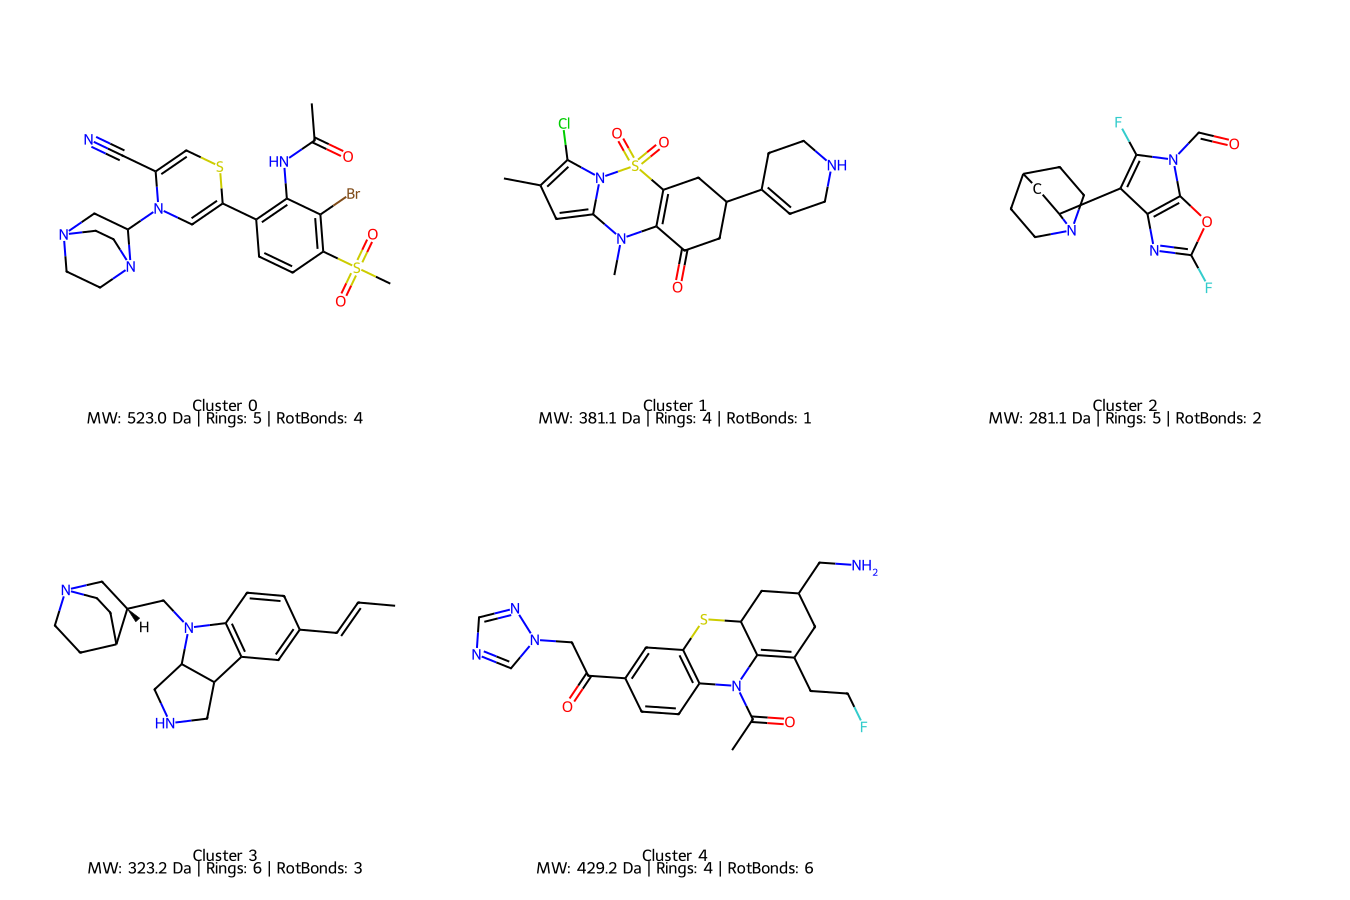

Successfully saved structure grid visualization as 'cluster_representatives_grid.png'


In [18]:
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from sklearn.metrics import pairwise_distances_argmin_min

# 1. Identify and extract the cluster representative compounds
closest_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_pca)
rep_df = df.iloc[closest_indices].copy().reset_index(drop=True)

# 2. Calculate structural properties for the representatives
rep_df['Molecular_Weight'] = rep_df['s_user_SMILES'].apply(lambda s: Descriptors.ExactMolWt(Chem.MolFromSmiles(s)))
rep_df['Ring_Count'] = rep_df['s_user_SMILES'].apply(lambda s: Descriptors.RingCount(Chem.MolFromSmiles(s)))
rep_df['Rotatable_Bonds'] = rep_df['s_user_SMILES'].apply(lambda s: Descriptors.NumRotatableBonds(Chem.MolFromSmiles(s)))

# 3. Convert SMILES text into RDKit molecule objects
mols = [Chem.MolFromSmiles(s) for s in rep_df['s_user_SMILES']]

# 4. Generate custom descriptive labels for each structure
legends = []
for idx, row in rep_df.iterrows():
    c_id = int(row['Cluster'])
    name = row['Name'] if 'Name' in row else f"Compound {idx}"
    mw = row['Molecular_Weight']
    rc = row['Ring_Count']
    rb = row['Rotatable_Bonds']

    legend_text = (
        f"Cluster {c_id}\n"
        f"MW: {mw:.1f} Da | Rings: {rc} | RotBonds: {rb}"
    )
    legends.append(legend_text)

# 5. Render the molecules into a grid image
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(450, 450),
    legends=legends
)

display(img)

# 6. Save the visualization to disk
if hasattr(img, 'save'):
    img.save('cluster_representatives_grid.png')

print("Successfully saved structure grid visualization as 'cluster_representatives_grid.png'")